# 01_data_understanding.ipynb

## Méthodologie

La structure d’analyse utilisée dans ce notebook suit le cadre défini
dans le fichier `méthode`, avec les rubriques :
- Observation
- Hypothèse
- Interprétation métier
- Décision pour la suite
- Note pour le rapport final

<br><br>

---

<br>

## 1. Chargement des données

### Chargement du dataset
✔ (9199930, 34)

In [4]:
import pandas as pd

df = pd.read_csv("../raw_data/methane_data.csv")

df.head()

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,...,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
0,2014,3,2,0,0,0,3.2,1.6,1.4,24.7,...,0.0,0.0,0.0,5.0,4.0,6.0,4.0,0.0,0.0,0.0
1,2014,3,2,0,0,1,3.2,1.6,1.4,24.7,...,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,0.0
2,2014,3,2,0,0,2,3.2,1.6,1.4,24.7,...,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0
3,2014,3,2,0,0,3,3.2,1.6,1.4,24.7,...,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0
4,2014,3,2,0,0,4,3.2,1.6,1.4,24.7,...,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0


### La shape

In [3]:
df.shape

(9199930, 34)

### Les colonnes :

In [4]:
df.columns

Index(['year', 'month', 'day', 'hour', 'minute', 'second', 'AN311', 'AN422',
       'AN423', 'TP1721', 'RH1722', 'BA1723', 'TP1711', 'RH1712', 'BA1713',
       'MM252', 'MM261', 'MM262', 'MM263', 'MM264', 'MM256', 'MM211', 'CM861',
       'CR863', 'P_864', 'TC862', 'WM868', 'AMP1_IR', 'AMP2_IR', 'DMP3_IR',
       'DMP4_IR', 'AMP5_IR', 'F_SIDE', 'V'],
      dtype='str')

### Mapping

In [5]:
column_mapping = {

"AN311": "airflow_311",
"AN422": "airflow_422",
"AN423": "airflow_423",

"TP1721": "temperature_1721",
"TP1711": "temperature_1711",

"RH1722": "humidity_1722",
"RH1712": "humidity_1712",

"BA1723": "pressure_1723",
"BA1713": "pressure_1713",

"MM252": "methane_252",
"MM261": "methane_261",
"MM262": "methane_262",
"MM263": "methane_263",
"MM264": "methane_264",
"MM256": "methane_256",
"MM211": "methane_211",

"CM861": "methane_high_861",
"CR863": "methane_pressure_diff",
"P_864": "methane_pipeline_pressure",
"TC862": "methane_pipeline_temperature",
"WM868": "methane_flow_rate",

"AMP1_IR": "cutter_head_left_current",
"AMP2_IR": "cutter_head_right_current",
"DMP3_IR": "haulage_left_current",
"DMP4_IR": "haulage_right_current",
"AMP5_IR": "hydraulic_pump_current",

"F_SIDE": "cutting_direction",
"V": "cutter_speed"
}

df = df.rename(columns=column_mapping)

### Types de données
✔ uniquement int et float

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9199930 entries, 0 to 9199929
Data columns (total 34 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   year                          int64  
 1   month                         int64  
 2   day                           int64  
 3   hour                          int64  
 4   minute                        int64  
 5   second                        int64  
 6   airflow_311                   float64
 7   airflow_422                   float64
 8   airflow_423                   float64
 9   temperature_1721              float64
 10  humidity_1722                 int64  
 11  pressure_1723                 float64
 12  temperature_1711              float64
 13  humidity_1712                 int64  
 14  pressure_1713                 float64
 15  methane_252                   float64
 16  methane_261                   float64
 17  methane_262                   float64
 18  methane_263                   flo

## Description des variables du dataset

In [7]:
description = {
    "year": ("Année de la mesure", "année"),
    "month": ("Mois de la mesure", "mois"),
    "day": ("Jour du mois", "jour"),
    "hour": ("Heure de la mesure", "heure"),
    "minute": ("Minute de la mesure", "minute"),
    "second": ("Seconde de la mesure", "seconde"),

    "airflow_311": ("Vitesse d’air anémomètre 311", "m/s"),
    "airflow_422": ("Vitesse d’air anémomètre 422", "m/s"),
    "airflow_423": ("Vitesse d’air anémomètre 423", "m/s"),

    "temperature_1721": ("Température capteur 1721", "°C"),
    "humidity_1722": ("Humidité relative capteur 1722", "%"),
    "pressure_1723": ("Pression atmosphérique capteur 1723", "hPa"),

    "temperature_1711": ("Température capteur 1711", "°C"),
    "humidity_1712": ("Humidité relative capteur 1712", "%"),
    "pressure_1713": ("Pression atmosphérique capteur 1713", "hPa"),

    "methane_252": ("Capteur méthane 252", "% vol"),
    "methane_261": ("Capteur méthane 261", "% vol"),
    "methane_262": ("Capteur méthane 262", "% vol"),
    "methane_263": ("Capteur méthane mur de taille", "% vol"),
    "methane_264": ("Capteur méthane renfoncement galerie", "% vol"),
    "methane_256": ("Capteur méthane aval galerie", "% vol"),
    "methane_211": ("Capteur méthane 211", "% vol"),

    "methane_high_861": ("Capteur méthane haute concentration", "% vol"),
    "methane_pressure_diff": ("Différence pression gaz", "Pa"),
    "methane_pipeline_pressure": ("Pression conduite méthane", "kPa"),
    "methane_pipeline_temperature": ("Température conduite méthane", "°C"),
    "methane_flow_rate": ("Débit méthane", "m³/s"),

    "cutter_head_left_current": ("Courant moteur tête de coupe gauche", "A"),
    "cutter_head_right_current": ("Courant moteur tête de coupe droite", "A"),

    "haulage_left_current": ("Courant traction gauche", "A"),
    "haulage_right_current": ("Courant traction droite", "A"),

    "hydraulic_pump_current": ("Courant pompe hydraulique", "A"),

    "cutting_direction": ("Direction de coupe", "-"),
    "cutter_speed": ("Vitesse tête de coupe", "rpm"),
}

In [8]:
import pandas as pd

rows = []

for col in df.columns:
    desc, unit = description.get(col, ("", ""))

    rows.append({
        "variable": col,
        "description": desc,
        "unit": unit,
        "dtype": df[col].dtype
    })

metadata_df = pd.DataFrame(rows)

metadata_df

,variable,description,unit,dtype
0,year,Année de la mesure,année,int64
1,month,Mois de la mesure,mois,int64
2,day,Jour du mois,jour,int64
3,hour,Heure de la mesure,heure,int64
4,minute,Minute de la mesure,minute,int64
5,second,Seconde de la mesure,seconde,int64
6,airflow_311,Vitesse d’air anémomètre 311,m/s,float64
7,airflow_422,Vitesse d’air anémomètre 422,m/s,float64
8,airflow_423,Vitesse d’air anémomètre 423,m/s,float64
9,temperature_1721,Température capteur 1721,°C,float64


Les variables du dataset correspondent à des mesures issues de différents
capteurs installés sur la machine d'extraction et dans la galerie.

Les concentrations de méthane sont exprimées en pourcentage volumique (% vol),
les vitesses d'air en mètres par seconde (m/s) et les courants moteurs en ampères (A).

Les types de données indiquent que la majorité des capteurs sont enregistrés
sous forme de valeurs continues (float64), tandis que les composantes
temporelles sont stockées sous forme d'entiers (int64).

### Valeurs manquantes
✔ aucune

In [9]:
df.isna().sum()

year                            0
month                           0
day                             0
hour                            0
minute                          0
second                          0
airflow_311                     0
airflow_422                     0
airflow_423                     0
temperature_1721                0
humidity_1722                   0
pressure_1723                   0
temperature_1711                0
humidity_1712                   0
pressure_1713                   0
methane_252                     0
methane_261                     0
methane_262                     0
methane_263                     0
methane_264                     0
methane_256                     0
methane_211                     0
methane_high_861                0
methane_pressure_diff           0
methane_pipeline_pressure       0
methane_pipeline_temperature    0
methane_flow_rate               0
cutter_head_left_current        0
cutter_head_right_current       0
haulage_left_c

### Statistiques descriptives et distribution générale des variables

In [10]:
pd.set_option('display.max_columns', None)

df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,9199930.0,2014.00,0.00,2014.0,2014.00,2014.0,2014.00,2014.00
month,9199930.0,4.30,1.03,3.0,3.00,4.0,5.00,6.00
day,9199930.0,14.87,8.71,1.0,7.00,14.0,22.00,31.00
hour,9199930.0,11.48,6.92,0.0,5.00,11.0,17.00,23.00
minute,9199930.0,29.50,17.32,0.0,14.00,29.0,44.00,59.00
second,9199930.0,29.50,17.32,0.0,14.00,29.0,44.00,59.00
airflow_311,9199930.0,3.48,0.61,-266.0,3.30,3.6,3.80,5.00
airflow_422,9199930.0,1.65,0.13,0.0,1.60,1.6,1.70,2.40
airflow_423,9199930.0,1.50,0.33,-2.4,1.40,1.4,1.50,5.30
temperature_1721,9199930.0,25.48,0.93,0.0,24.70,25.4,26.10,27.90


Les statistiques descriptives permettent d'obtenir une première vue
d'ensemble des variables du dataset : valeurs moyennes, dispersion,
quartiles et valeurs extrêmes.

Cette étape permet notamment de vérifier l'ordre de grandeur des mesures
et de détecter d'éventuelles anomalies dans les données.

Certaines valeurs extrêmes sont observées dans les mesures d'anémométrie
(par exemple airflow_311 = -266). Bien qu’un flux d’air négatif puisse
indiquer une inversion locale du courant d’air, une valeur de cette
amplitude paraît physiquement improbable et pourrait correspondre à
une erreur de mesure ou à une valeur codant une anomalie capteur.

### Quelle proportion du temps la mine dépasse 1% de méthane ?

In [11]:
print("263 :", (df["methane_263"] >= 1).mean())
print("264 :", (df["methane_264"] >= 1).mean())
print("256 :", (df["methane_256"] >= 1).mean())

263 : 0.002043711202150451
264 : 0.00840767266707464
256 : 0.012478355813576843


### Quelle proportion du temps la mine dépasse 1,5% de méthane ?

In [12]:
print("263 :", (df["methane_263"] >= 1.5).mean())
print("264 :", (df["methane_264"] >= 1.5).mean())
print("256 :", (df["methane_256"] >= 1.5).mean())

263 : 0.00012271832503073392
264 : 0.000413372710444536
256 : 0.00011532696444429469


Analyse des seuils de concentration de méthane

L'analyse des trois capteurs critiques situés au niveau du front de taille
(methane_263, methane_264 et methane_256) montre que les concentrations
élevées de méthane restent rares dans le dataset.

Les dépassements du seuil d'avertissement (1 % CH4) représentent environ
0.2 % à 1.25 % des observations selon le capteur. Ces événements
correspondent à des situations où la concentration de méthane devient
suffisamment élevée pour nécessiter une vigilance accrue de l'exploitation.

En revanche, les dépassements du seuil critique (1.5 % CH4), qui
déclenchent généralement un arrêt de sécurité de l'exploitation, sont
extrêmement rares et représentent moins de 0.05 % des observations.

Ces résultats confirment deux caractéristiques importantes du problème :

1. **Les situations dangereuses sont exceptionnelles dans le fonctionnement
normal de la mine.**

2. **Le dataset est fortement déséquilibré, ce qui rend la prédiction directe
du seuil critique difficile pour un modèle de machine learning.**

Pour cette raison, l'approche retenue dans la littérature consiste
généralement à prédire l'approche du seuil d'avertissement (1 % CH4)
quelques minutes à l'avance, afin d'anticiper les conditions menant
potentiellement à un arrêt de production.

## Corrélation entre les trois capteurs critiques

In [13]:
df[["methane_263","methane_264","methane_256"]].corr()

,methane_263,methane_264,methane_256
methane_263,1.000000,0.245790,0.178427
methane_264,0.245790,1.000000,0.407354
methane_256,0.178427,0.407354,1.000000


La corrélation entre les trois capteurs critiques de méthane reste relativement
faible à modérée (0.17 à 0.41).

Cela indique que les capteurs ne mesurent pas exactement les mêmes concentrations
de méthane mais captent des variations locales différentes au niveau du front
de taille.

Le couple methane_264 et methane_256 présente la corrélation la plus élevée,
ce qui suggère une proximité spatiale plus importante ou une exposition similaire
au flux de méthane.

Cette faible corrélation confirme l'intérêt de conserver les trois capteurs
comme variables distinctes dans la modélisation.

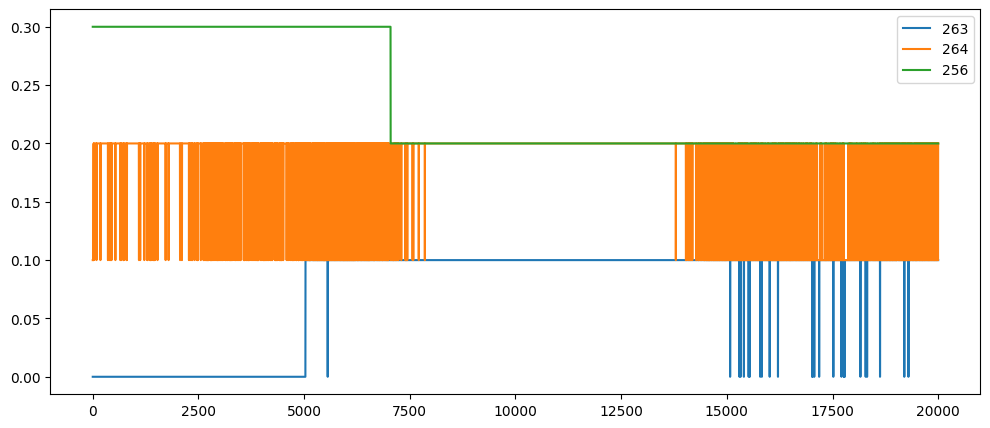

In [14]:
sample = df.iloc[:20000]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(sample["methane_263"], label="263")
plt.plot(sample["methane_264"], label="264")
plt.plot(sample["methane_256"], label="256")

plt.legend()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

img = mpimg.imread("docs/mine_schema.jpg")

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)
ax.axis("off")

airflow_positions = {
    "airflow_311": (521, 133),
    "airflow_422": (275, 155),
    "airflow_423": (395, 250),
}

airflow_colors = {
    "airflow_311": "blue",
    "airflow_422": "orange",
    "airflow_423": "green",
}

methane_positions = {
    "methane_263": (88, 162),
    "methane_264": (85, 144),
    "methane_256": (142, 150),
}

methane_colors = {
    "methane_263": "red",
    "methane_264": "purple",
    "methane_256": "brown",
}

for sensor, (x, y) in airflow_positions.items():
    ax.scatter(x, y, s=140, color=airflow_colors[sensor], edgecolor="black")

for sensor, (x, y) in methane_positions.items():
    ax.scatter(x, y, s=140, color=methane_colors[sensor], edgecolor="black")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='airflow_311', markerfacecolor='blue', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='airflow_422', markerfacecolor='orange', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='airflow_423', markerfacecolor='green', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='methane_263', markerfacecolor='red', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='methane_264', markerfacecolor='purple', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='methane_256', markerfacecolor='brown', markeredgecolor='black', markersize=10),
]

ax.legend(handles=legend_elements, loc="lower left", bbox_to_anchor=(0, -0.05), ncol=3, frameon=False)

plt.title("Localisation des anémomètres et capteurs méthane critiques")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'docs/mine_schema.jpg'

### Interprétation spatiale des capteurs

Le schéma de la galerie montre que les trois capteurs critiques de méthane sont localisés à proximité immédiate de la zone d’exploitation (longwall), où l’extraction du charbon libère du méthane contenu dans la roche.

Les capteurs `methane_263` et `methane_264` sont situés très près du front d’abattage, ce qui explique qu’ils puissent détecter rapidement les augmentations de concentration en méthane lors des phases d’extraction.

Le capteur `methane_256`, légèrement plus éloigné dans la galerie, semble détecter les variations de méthane après que le gaz a commencé à se diffuser dans le flux de ventilation.

Cette disposition suggère que les capteurs mesurent des phénomènes similaires mais à des positions différentes le long du circuit d’air, ce qui peut expliquer les décalages observés dans l’apparition des pics de concentration entre les capteurs.

## Interprétation des différences entre les capteurs critiques de méthane

Les analyses exploratoires montrent que les trois capteurs critiques de méthane (methane_263, methane_264, methane_256) présentent des comportements différents, avec des fréquences de dépassement de seuil variables (1 % et 1,5 %) et une corrélation relativement faible entre leurs mesures. Cela suggère que les concentrations de méthane observées sont influencées par des phénomènes locaux dans la galerie plutôt que par un nuage homogène de gaz.

Plusieurs facteurs physiques et opérationnels peuvent expliquer ces différences :

Position des capteurs dans la galerie.
Le capteur 263 est situé au niveau du mur de taille, une zone généralement fortement ventilée et soumise à un brassage d’air important, ce qui peut limiter l’accumulation locale de méthane.
Le capteur 264, placé dans un renfoncement de la galerie, pourrait être plus sensible à des phénomènes d’accumulation locale du gaz en raison d’une circulation d’air moins efficace. Cela pourrait expliquer des dépassements plus fréquents du seuil critique de 1,5 %.
Le capteur 256, situé plus en aval dans la galerie après un virage, observe davantage de dépassements du seuil de 1 %.

Influence possible de la géométrie de la galerie et de la ventilation.
Les virages et irrégularités de la galerie peuvent créer des zones de turbulence ou de stagnation du flux d’air, favorisant localement l’accumulation de méthane.

Désorption progressive du méthane contenu dans le charbon extrait.
Le charbon continue à relarguer du méthane après son extraction. Le transport du charbon sur les convoyeurs, jusqu’à la surface, peut donc constituer une source secondaire de méthane dans la galerie.
Il est possible qu’une zone de transfert entre convoyeurs ou une zone de forte agitation du charbon (par exemple dans un virage) accélère la libération du gaz, ce qui pourrait contribuer aux concentrations observées par le capteur 256.

Effet potentiel des sprays d’eau utilisés au front de taille.
Les systèmes de pulvérisation d’eau, principalement utilisés pour la maîtrise des poussières, peuvent également modifier localement les conditions d’écoulement de l’air et la turbulence. Cela peut influencer la dispersion du méthane sans nécessairement réduire directement la quantité totale de gaz libérée.

Ces éléments constituent des hypothèses physiques plausibles permettant d’interpréter les différences observées entre les capteurs. Une analyse plus approfondie intégrant les mesures de ventilation (anémomètres), les paramètres de fonctionnement de la machine et le plan exact des installations pourrait permettre de confirmer ou d’infirmer ces interprétations.

### Note pour le rapport final

L’analyse des trois capteurs critiques de méthane (`methane_263`, `methane_264`, `methane_256`) montre que les dépassements du seuil d’avertissement de 1 % restent rares mais suffisamment fréquents pour constituer une cible pertinente de modélisation. À l’inverse, les dépassements du seuil critique de 1.5 % sont beaucoup plus rares, ce qui rend leur prédiction directe moins adaptée dans un premier temps.

Les corrélations observées entre les trois capteurs restent faibles à modérées, ce qui suggère qu’ils ne mesurent pas un signal strictement redondant mais des variations locales du méthane dans des zones différentes de la galerie.

Ces résultats justifient deux choix méthodologiques :
1. conserver les trois capteurs comme variables distinctes dans l’analyse ;
2. privilégier une cible fondée sur le seuil de 1 % CH4 pour la suite du projet de prédiction.

---

## Analyse de la dynamique temporelle avant dépassement du seuil

---

Corrélation ventilation / méthane

In [16]:
df[
    [
        "methane_263",
        "methane_264",
        "methane_256",
        "airflow_311",
        "airflow_422",
        "airflow_423"
    ]
].corr()

,methane_263,methane_264,methane_256,airflow_311,airflow_422,airflow_423
methane_263,1.000000,0.245790,0.178427,0.048432,-0.123898,0.054792
methane_264,0.245790,1.000000,0.407354,-0.055296,-0.143138,0.080998
methane_256,0.178427,0.407354,1.000000,-0.123308,-0.163638,0.122969
airflow_311,0.048432,-0.055296,-0.123308,1.000000,-0.220884,-0.172705
airflow_422,-0.123898,-0.143138,-0.163638,-0.220884,1.000000,0.175392
airflow_423,0.054792,0.080998,0.122969,-0.172705,0.175392,1.000000


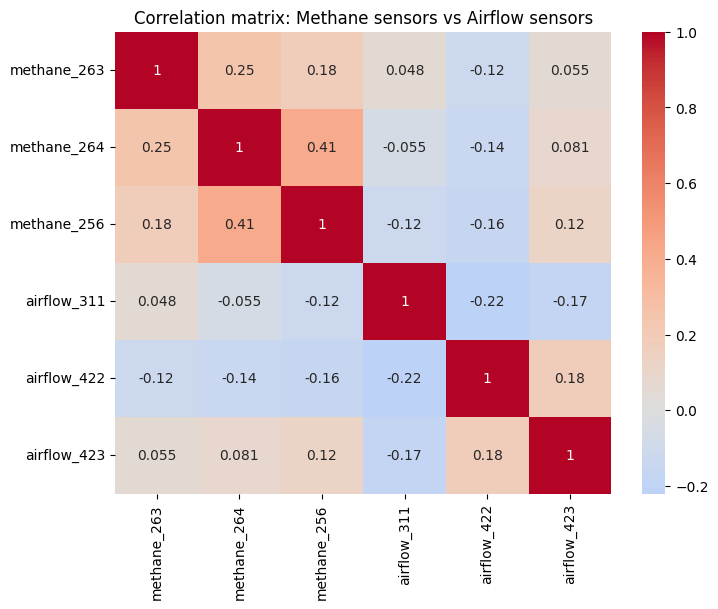

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "methane_263",
    "methane_264",
    "methane_256",
    "airflow_311",
    "airflow_422",
    "airflow_423"
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation matrix: Methane sensors vs Airflow sensors")
plt.show()

In [18]:
df_sample = df.sample(200000, random_state=42)

In [19]:
df_sample.shape

(200000, 34)

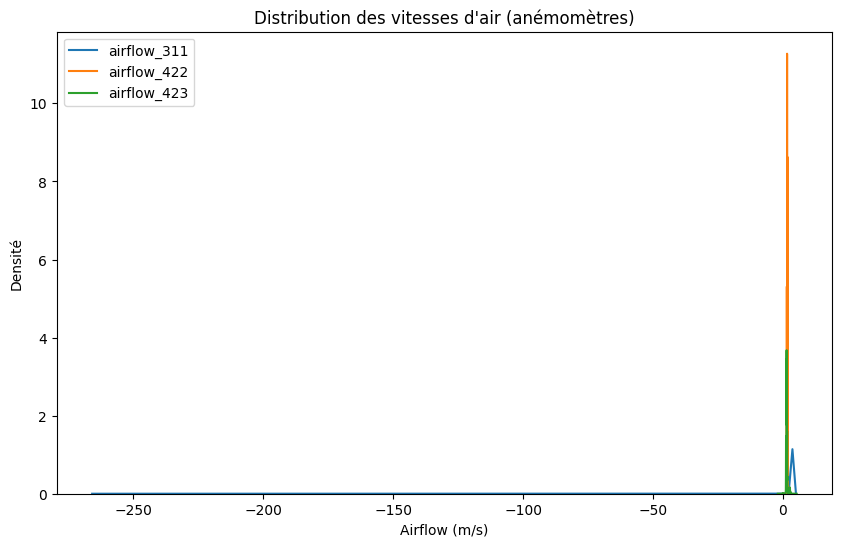

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

airflow_cols = [
    "airflow_311",
    "airflow_422",
    "airflow_423"
]

plt.figure(figsize=(10,6))

for col in airflow_cols:
    sns.kdeplot(df_sample[col], label=col, fill=False)

plt.title("Distribution des vitesses d'air (anémomètres)")
plt.xlabel("Airflow (m/s)")
plt.ylabel("Densité")
plt.legend()

plt.show()

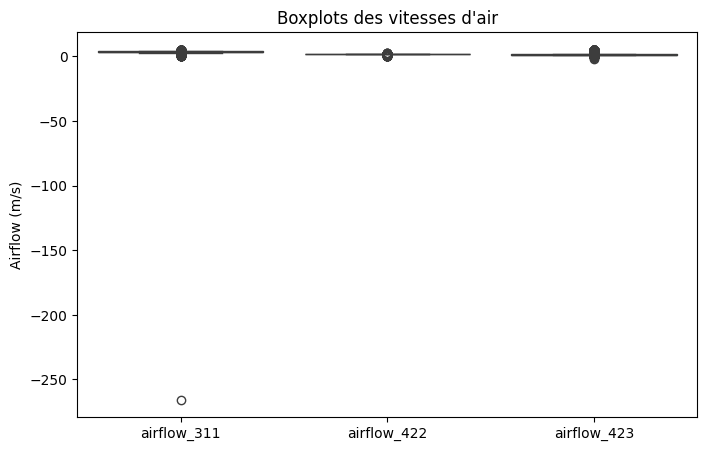

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

airflow_cols = ["airflow_311", "airflow_422", "airflow_423"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_sample[airflow_cols])

plt.title("Boxplots des vitesses d'air")
plt.ylabel("Airflow (m/s)")
plt.show()

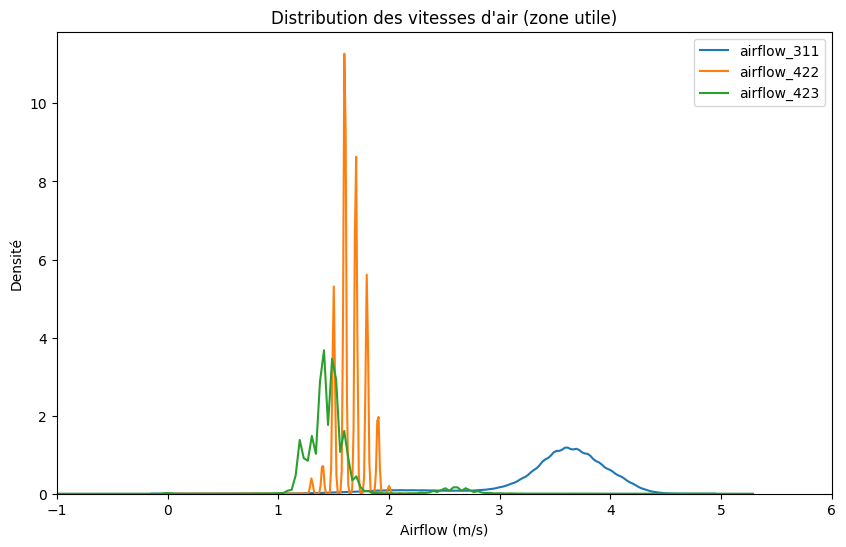

In [22]:
plt.figure(figsize=(10,6))

for col in airflow_cols:
    sns.kdeplot(
        df_sample[col][df_sample[col] > -5],  # on enlève l'outlier extrême
        label=col
    )

plt.title("Distribution des vitesses d'air (zone utile)")
plt.xlabel("Airflow (m/s)")
plt.ylabel("Densité")
plt.xlim(-1,6)

plt.legend()
plt.show()

Les distributions des vitesses d'air mesurées par les anémomètres montrent
des différences importantes entre les galeries.

Le capteur airflow_311 présente des vitesses d'air nettement plus élevées
(autour de 3.5 m/s), ce qui suggère qu'il est situé dans une galerie
principale fortement ventilée.

Les capteurs airflow_422 et airflow_423 mesurent des vitesses plus faibles,
comprises entre 1.2 et 1.8 m/s, indiquant des zones de ventilation secondaire.

Ces différences de ventilation peuvent influencer la dispersion et la
dilution du méthane libéré lors de l'extraction du charbon.

In [23]:
df_airflow_plot = df_sample[
    (df_sample["airflow_311"] > -5) &
    (df_sample["airflow_422"] > -5) &
    (df_sample["airflow_423"] > -5)
]

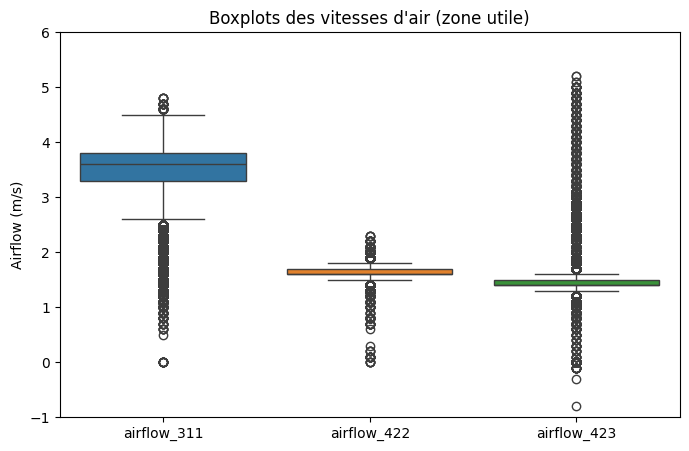

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_airflow_plot[airflow_cols])

plt.title("Boxplots des vitesses d'air (zone utile)")
plt.ylabel("Airflow (m/s)")
plt.ylim(-1,6)

plt.show()

Les boxplots confirment les différences de ventilation entre les galeries.

Le capteur airflow_311 présente les vitesses d'air les plus élevées,
avec une médiane autour de 3.5 m/s, ce qui correspond probablement à
une galerie principale fortement ventilée.

Les capteurs airflow_422 et airflow_423 mesurent des vitesses plus
faibles, indiquant des zones de ventilation secondaire.

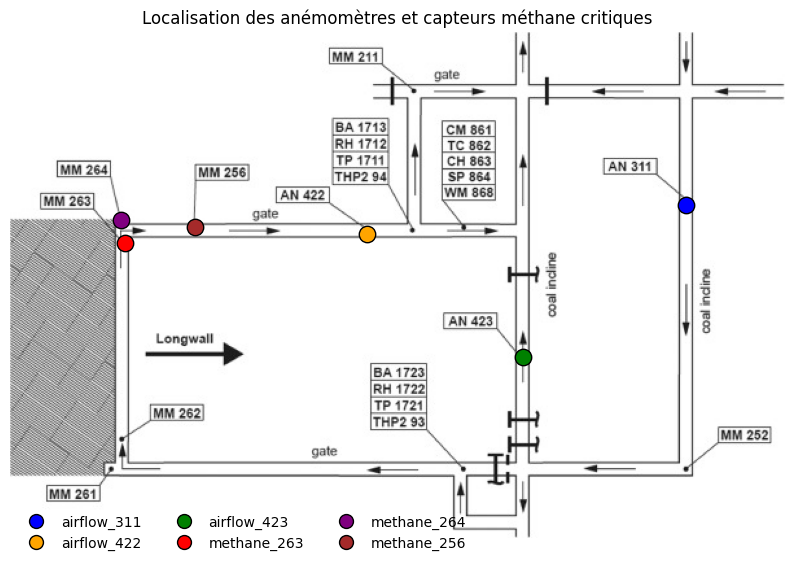

In [25]:
(df["airflow_423"] < 0).mean()

np.float64(7.58701424902146e-05)

In [26]:
df[df["airflow_423"] < 0]["airflow_423"].describe()

count    698.000000
mean      -0.544986
std        0.650579
min       -2.400000
25%       -0.700000
50%       -0.200000
75%       -0.100000
max       -0.100000
Name: airflow_423, dtype: float64

### Observation

Les distributions et boxplots des trois anémomètres montrent des différences nettes entre les zones de la mine.

- `airflow_311` présente les vitesses d’air les plus élevées, avec une distribution centrée autour de 3.5 m/s.
- `airflow_422` présente des vitesses intermédiaires, autour de 1.6–1.8 m/s.
- `airflow_423` présente les vitesses les plus faibles, autour de 1.2–1.5 m/s, ainsi que quelques valeurs négatives.

### Hypothèse

Ces différences suggèrent que les trois anémomètres ne sont pas situés dans des zones de ventilation équivalentes.

- `airflow_311` pourrait correspondre à une galerie principale ou à une zone plus fortement ventilée.
- `airflow_422` et `airflow_423` pourraient correspondre à des zones secondaires ou plus perturbées du réseau de ventilation.
- Les valeurs négatives observées pour `airflow_423` peuvent correspondre à des perturbations locales du flux, à des turbulences, ou à des mesures aberrantes.

### Interprétation métier

Dans une mine en fonctionnement, la ventilation est un élément critique de sécurité car elle permet la dilution et l’évacuation du méthane.

Des vitesses d’air plus faibles ou localement instables peuvent donc favoriser l’accumulation de méthane dans certaines zones de la galerie. Les anémomètres apparaissent ainsi comme des variables explicatives importantes pour comprendre les futurs dépassements de seuil des capteurs de méthane.

### Décision pour la suite

Conserver les trois anémomètres comme variables distinctes dans l’analyse, car ils semblent décrire des zones de ventilation différentes.

Les variables de ventilation seront étudiées plus loin en lien avec les dépassements de méthane, afin de vérifier si une baisse de l’airflow précède les pics de CH4.

### Note pour le rapport final

L’analyse descriptive des anémomètres met en évidence une ventilation hétérogène entre les zones surveillées de la mine. Cette hétérogénéité pourrait contribuer aux différences observées dans les niveaux de méthane mesurés par les capteurs critiques.

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

img = mpimg.imread("docs/mine_schema.jpg")

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)
ax.axis("off")

airflow_positions = {
    "airflow_311": (521, 133),
    "airflow_422": (275, 155),
    "airflow_423": (395, 250),
}

airflow_colors = {
    "airflow_311": "blue",
    "airflow_422": "orange",
    "airflow_423": "green",
}

methane_positions = {
    "methane_263": (88, 162),
    "methane_264": (85, 144),
    "methane_256": (142, 150),
}

methane_colors = {
    "methane_263": "red",
    "methane_264": "purple",
    "methane_256": "brown",
}

for sensor, (x, y) in airflow_positions.items():
    ax.scatter(x, y, s=140, color=airflow_colors[sensor], edgecolor="black")

for sensor, (x, y) in methane_positions.items():
    ax.scatter(x, y, s=140, color=methane_colors[sensor], edgecolor="black")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='airflow_311', markerfacecolor='blue', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='airflow_422', markerfacecolor='orange', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='airflow_423', markerfacecolor='green', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='methane_263', markerfacecolor='red', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='methane_264', markerfacecolor='purple', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='methane_256', markerfacecolor='brown', markeredgecolor='black', markersize=10),
]

ax.legend(handles=legend_elements, loc="lower left", bbox_to_anchor=(0, -0.05), ncol=3, frameon=False)

plt.title("Localisation des anémomètres et capteurs méthane critiques")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'docs/mine_schema.jpg'

<br><br>

---

<br>

# EDA temporelle autour des événements

---

# 2. Analyse temporelle avant dépassement de méthane

Objectif : comprendre l’évolution des capteurs dans les minutes précédant un dépassement de 1% de méthane.

Cela permet d’identifier des signaux précurseurs exploitables par un modèle de machine learning.

In [28]:
df["timestamp"] = pd.to_datetime(
    df[["year", "month", "day", "hour", "minute", "second"]]
)
df = df.sort_values("timestamp").reset_index(drop=True)

df[["timestamp"]].head()

,timestamp
0,2014-03-02 00:00:00
1,2014-03-02 00:00:01
2,2014-03-02 00:00:02
3,2014-03-02 00:00:03
4,2014-03-02 00:00:04


In [29]:
df["methane_max"] = df[
    ["methane_263", "methane_264", "methane_256"]
].max(axis=1)

df["warning_1pct"] = (df["methane_max"] >= 1).astype(int)

df["warning_1pct"].mean()

np.float64(0.022197777591786025)

In [30]:
event_index = df.index[df["warning_1pct"] == 1][0]
event_index

np.int64(204370)

In [31]:
window = df.iloc[event_index-600:event_index+540]

window.shape

(1140, 37)

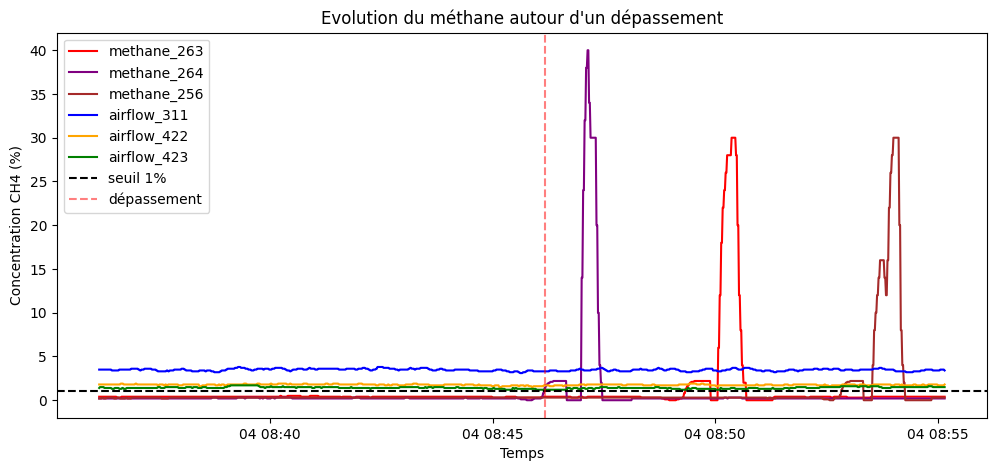

In [32]:
plt.figure(figsize=(12,5))

plt.plot(window["timestamp"], window["methane_263"], color="red", label="methane_263")
plt.plot(window["timestamp"], window["methane_264"], color="purple", label="methane_264")
plt.plot(window["timestamp"], window["methane_256"], color="brown", label="methane_256")
plt.plot(window["timestamp"], window["airflow_311"], color="blue", label="airflow_311")
plt.plot(window["timestamp"], window["airflow_422"], color="orange", label="airflow_422")
plt.plot(window["timestamp"], window["airflow_423"], color="green", label="airflow_423")

plt.axhline(1, linestyle="--", color="black", label="seuil 1%")

event_time = df.loc[event_index, "timestamp"]
plt.axvline(event_time, linestyle="--", color="red", alpha=0.5, label="dépassement")

plt.legend()

plt.title("Evolution du méthane autour d'un dépassement")
plt.xlabel("Temps")
plt.ylabel("Concentration CH4 (%)")

plt.show()

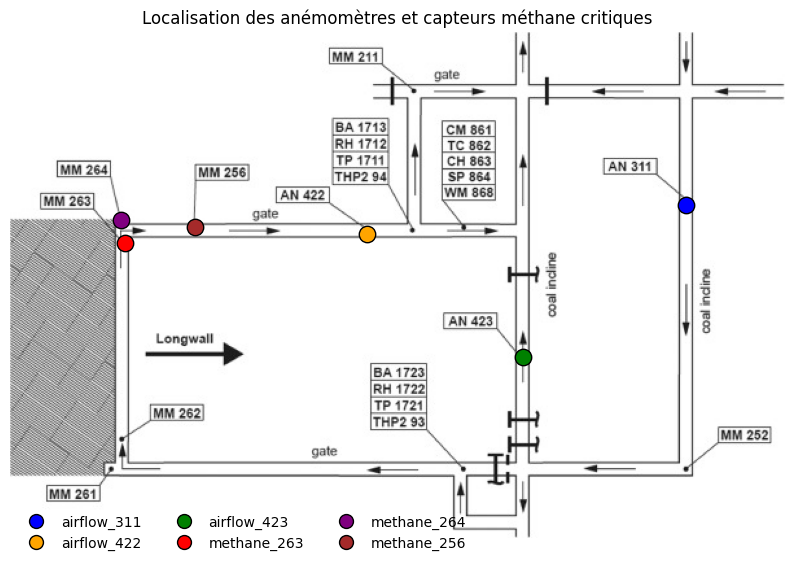

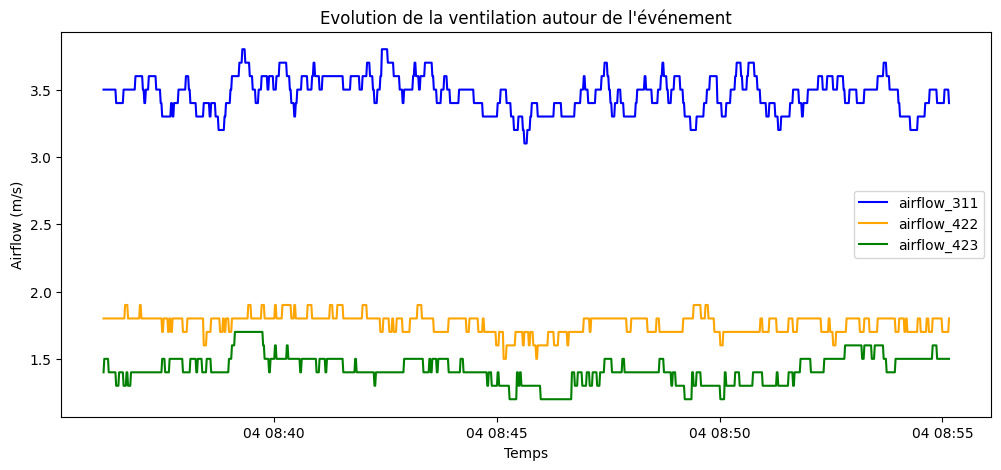

In [33]:
plt.figure(figsize=(12,5))

plt.plot(window["timestamp"], window["airflow_311"], color="blue", label="airflow_311")
plt.plot(window["timestamp"], window["airflow_422"], color="orange", label="airflow_422")
plt.plot(window["timestamp"], window["airflow_423"], color="green", label="airflow_423")

plt.legend()
plt.title("Evolution de la ventilation autour de l'événement")
plt.xlabel("Temps")
plt.ylabel("Airflow (m/s)")

plt.show()

In [34]:
event_index_33 = df.index[df["warning_1pct"] == 1][33]
event_index_33

np.int64(204423)

Étape 1 — identifier les débuts d'événements

In [35]:
df["event_start"] = (df["warning_1pct"] == 1) & (df["warning_1pct"].shift(1) == 0)

df["event_start"].sum()

np.int64(7911)

### Observation

Le nombre de débuts d’événements détectés est de **7 911**.

### Interprétation métier

Cela signifie que les dépassements du seuil warning (1 % CH4) ne se produisent pas sous la forme de quelques incidents isolés uniquement, mais sous la forme de nombreux épisodes distincts répartis dans le temps.

Le signal d’alerte est donc fragmenté en plusieurs événements, dont chacun peut durer plusieurs secondes.

### Décision pour la suite

Il faudra distinguer les **événements distincts** du simple nombre total de lignes en alerte, afin de mieux caractériser la fréquence et la durée réelle des dépassements.

Étape 2 — récupérer les timestamps

In [36]:
events = df.loc[df["event_start"], "timestamp"]

events.head()

204370   2014-03-04 08:46:10
204420   2014-03-04 08:47:00
204560   2014-03-04 08:49:20
204604   2014-03-04 08:50:04
204770   2014-03-04 08:52:50
Name: timestamp, dtype: datetime64[us]

Étape 3 — regarder la distribution temporelle

In [37]:
events.diff().describe()

count                      7910
mean     0 days 00:18:34.402907
std      0 days 03:36:07.803086
min             0 days 00:00:04
25%             0 days 00:00:12
50%             0 days 00:00:24
75%             0 days 00:01:04
max             8 days 00:29:15
Name: timestamp, dtype: object

Étape 4 — vérifier les valeurs maximales lors des événements

In [38]:
df.loc[df["warning_1pct"] == 1, "methane_max"].describe()

count    204218.000000
mean          1.133035
std           0.983578
min           1.000000
25%           1.000000
50%           1.000000
75%           1.100000
max          40.000000
Name: methane_max, dtype: float64

In [39]:
df["event_id"] = df["event_start"].cumsum()

events_duration = (
    df[df["warning_1pct"] == 1]
    .groupby("event_id")
    .size()
)

events_duration.describe()

count     7911.000000
mean        25.814436
std        197.117774
min          2.000000
25%          4.000000
50%          6.000000
75%         14.000000
max      14999.000000
dtype: float64

# To-do notebook — Data Understanding

## 1. Nettoyage / structuration du notebook
- [ ] Réorganiser les sections dans un ordre logique
- [ ] Supprimer ou fusionner les cellules redondantes
- [ ] Harmoniser les titres et sous-titres
- [ ] Ajouter des cellules markdown de synthèse après chaque bloc important
- [ ] Ajouter des encadrés "Observation", "Interprétation métier", "Décision / suite"

## 2. Chargement et description du dataset
- [x] Charger le dataset local
- [x] Vérifier `df.shape`
- [x] Vérifier `df.columns`
- [x] Vérifier `df.info()`
- [x] Vérifier l'absence de valeurs manquantes
- [x] Renommer les colonnes pour améliorer la lisibilité
- [x] Construire un tableau des variables avec description, unité et dtype
- [x] Ajouter ce tableau dans une section dédiée, proprement mise en forme

## 3. Statistiques descriptives
- [x] Calculer `df.describe()`
- [ ] Afficher la version lisible (`.T.round(2)`)
- [ ] Ajouter un commentaire général sur les ordres de grandeur
- [ ] Signaler explicitement les valeurs extrêmes ou physiquement suspectes

## 4. Analyse des capteurs méthane critiques
- [x] Identifier les trois capteurs critiques : `methane_263`, `methane_264`, `methane_256`
- [x] Relever leurs médianes et leurs distributions générales
- [x] Calculer la fréquence des dépassements `> 1 %`
- [x] Calculer la fréquence des dépassements `> 1.5 %`
- [x] Produire un tableau des dépassements `> 1 %`
- [x] Produire un tableau des dépassements `> 1.5 %`
- [x] Rédiger un commentaire comparatif des deux seuils
- [x] Calculer la corrélation entre les trois capteurs
- [x] Produire un graphique temporel simple des trois capteurs
- [x] Rédiger une interprétation métier / physique des différences entre capteurs
- [ ] Reformuler proprement cette interprétation dans une cellule markdown "Note pour le rapport final"

## 5. Analyse des anémomètres
- [x] Produire une heatmap methane ↔ airflow
- [x] Classer les corrélations principales
- [x] Produire une figure de distribution des airflow
- [x] Produire des boxplots des airflow
- [x] Identifier les valeurs négatives / aberrantes
- [x] Quantifier la proportion de valeurs négatives de `airflow_423`
- [x] Décrire les valeurs négatives de `airflow_423`
- [ ] Ajouter une synthèse claire sur le rôle possible des anémomètres dans la sécurité
- [ ] Ajouter une synthèse claire sur l'interprétation des faibles / nulles / négatives vitesses d'air

## 6. Schéma de la mine
- [ ] Ajouter le schéma de la mine dans le notebook
- [ ] Surligner les capteurs méthane critiques avec les mêmes couleurs que dans les graphes
- [ ] Surligner les anémomètres avec les mêmes couleurs que dans les graphes
- [ ] Ajouter une légende cohérente
- [ ] Ajouter une interprétation spatiale : front de taille, renfoncement, virage, galerie principale, galerie secondaire

## 7. Analyse temporelle (prochaine grande étape)
- [ ] Construire une colonne `timestamp`
- [ ] Trier le dataset selon le temps
- [ ] Identifier des événements de dépassement `> 1 %`
- [ ] Visualiser les 10 minutes précédant un dépassement
- [ ] Vérifier si la montée du méthane est progressive ou brutale
- [ ] Vérifier si les trois capteurs montent avec un décalage
- [ ] Vérifier si l'airflow chute avant les pics de méthane

## 8. Analyse de l'activité machine
- [ ] Étudier `cutter_speed`
- [ ] Étudier `cutting_direction`
- [ ] Étudier les courants moteurs
- [ ] Vérifier si la machine est active lors des pics de méthane
- [ ] Relier activité machine + ventilation + méthane

## 9. Construction de la cible ML
- [ ] Valider le choix du seuil principal (`1 %`)
- [ ] Définir la cible `y`
- [ ] Définir la fenêtre d'observation passée
- [ ] Définir l'horizon futur
- [ ] Justifier pourquoi `1.5 %` est trop rare comme cible principale

## 10. Préparation du rapport final
- [ ] Conserver dans le notebook des notes "pour le rapport final"
- [ ] Reporter les observations validées au bon niveau de formalisation
- [ ] Attendre la fin de l'EDA et de la modélisation avant de rédiger le rapport scientifique final